<a href="https://colab.research.google.com/github/ChyTalksTech/Inventory_Write-offs/blob/feature%2Fevaluation-xai/Inventory_Write_offs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimising the Health of Global Inventory through Automated Write-off prediction and root cause clustering

### Github Repository Link: https://github.com/ChyTalksTech/Inventory_Write-offs/

library Imports: Pandas, Sklearn, XGBoost, TensorFlow, SHAP

In [491]:
# Library Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from re import M

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import mean_absolute_error, r2_score
from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#Model Evaluation
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import precision_recall_curve, auc
import shap


## #1 Data Ingestion and Cleaning

initial cleaning and joins were done in snowflake via a query


### Pre-processing & SQL Extraction


In [492]:
MSEG_df = pd.read_csv('MSEG.csv')

MSEG_df.head()

,ROW_ID,YEAR,DATE,BRAND_ID,BRAND_NAME,MSEG_MATERIAL_NUMBER,MATERIAL_NAME,MATERIAL_TYPE_CODE,MATERIAL_TYPE_DESCRIPTION,MOVEMENT_TYPE_CODE,...,G/L_ACCOUNT_NAME,lOCAL_CURRENCY,CURRENCY_CONVERSION,AMOUNT_IN_lOCAL_CURRENCY,AMOUNT_IN_USD,ALTERNATIVE_AMOUNT,VALUATION_TYPE,GROUP_Cost_USD,Expiry_Date,QUANTITY
0,20840660,2025,20250626,3010,SYMBICORT TURBUHALER,191004358,SYMBICORT TURB 200/6MCG/D 1X120D CA,ZFIN,Finished Material,555,...,Inventory Write-off - Scrap / Destruction,CAD,0.71767,439.80,315.631266,438.34,NaN,13.109175,20280131,6.0
1,21112414,2025,20251014,3077,AIRSUPRA,110025621,AIRSUPRA 90/80MCG PMDI 120D US,ZFIN,Finished Material,963,...,Inventory Write-off - Scrap / Destruction,USD,-1.00000,120.60,120.600000,172.24,NaN,83.782959,20271231,15.0
2,21112492,2025,20251014,3045,BREZTRI,110022880,BREZTRI 160/9/4.8MCG PMDI 1X120D DFP US,ZFIN,Finished Material,963,...,Inventory Write-off - Scrap / Destruction,USD,-1.00000,497.80,497.800000,521.04,NaN,160.602483,20270930,20.0
3,20756277,2025,20250522,1026,FARXIGA,100003074,FORXIGA TAB 10MG BL 2X14 EA CO,ZFIN,Finished Material,555,...,Inventory Write-off - Scrap / Destruction,USD,-1.00000,116.07,116.070000,115.92,NaN,18.015873,20280229,6.0
4,21252553,2025,20251216,2032,TAGRISSO,100004821,TAGRISSO TAB 80MG BL 3X10 EA CA,ZFIN,Finished Material,555,...,Inventory Write-off - Scrap / Destruction,CAD,0.71767,7690.00,5518.882300,7682.55,NaN,36.426861,20271231,2.0


In [493]:
MSEG_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ROW_ID                     1494 non-null   int64  
 1   YEAR                       1494 non-null   int64  
 2   DATE                       1494 non-null   int64  
 3   BRAND_ID                   1494 non-null   int64  
 4   BRAND_NAME                 1494 non-null   object 
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object 
 6   MATERIAL_NAME              1494 non-null   object 
 7   MATERIAL_TYPE_CODE         1494 non-null   object 
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object 
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64  
 10  MOVEMENT_TYPE              1494 non-null   object 
 11  G/L_ACCOUNT                1494 non-null   int64  
 12  G/L_ACCOUNT_NAME           1494 non-null   object 
 13  lOCAL_CURRENCY             1494 non-null   objec

Notes:

*   Date and Expiry Date should be date not int64
*   Valuation Type is fully null so can delete
*   Some group cost is null. can rectify by forward filling material first and then using Median if Material type does not have other dates






In [494]:
# Converting Date from Int to Date
MSEG_df['DATE'] = pd.to_datetime(MSEG_df['DATE'].astype(str), format='%Y%m%d')
MSEG_df['Expiry_Date'] = pd.to_datetime(MSEG_df['Expiry_Date'].astype(str), format='%Y%m%d')

# Removing Valuation Type Column
MSEG_df.drop(columns=['VALUATION_TYPE'], inplace=True)

MSEG_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ROW_ID                     1494 non-null   int64         
 1   YEAR                       1494 non-null   int64         
 2   DATE                       1494 non-null   datetime64[ns]
 3   BRAND_ID                   1494 non-null   int64         
 4   BRAND_NAME                 1494 non-null   object        
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object        
 6   MATERIAL_NAME              1494 non-null   object        
 7   MATERIAL_TYPE_CODE         1494 non-null   object        
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object        
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64         
 10  MOVEMENT_TYPE              1494 non-null   object        
 11  G/L_ACCOUNT                1494 non-null   int64         
 12  G/L_AC

In [495]:
#1. Forward filling in nulls in Group Cost


# Sort by material and date first
MSEG_df = MSEG_df.sort_values(by=['MSEG_MATERIAL_NUMBER', 'DATE'])

# Forward fill costs within each material group
MSEG_df['GROUP_Cost_USD'] = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].ffill()

MSEG_df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 1494 entries, 1260 to 1348
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ROW_ID                     1494 non-null   int64         
 1   YEAR                       1494 non-null   int64         
 2   DATE                       1494 non-null   datetime64[ns]
 3   BRAND_ID                   1494 non-null   int64         
 4   BRAND_NAME                 1494 non-null   object        
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object        
 6   MATERIAL_NAME              1494 non-null   object        
 7   MATERIAL_TYPE_CODE         1494 non-null   object        
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object        
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64         
 10  MOVEMENT_TYPE              1494 non-null   object        
 11  G/L_ACCOUNT                1494 non-null   int64         
 12  G/L_ACCO

In [496]:
# Still some nulls so will use median

# Calculate median cost per Material Type (e.g., 'Finished Material')
material_type_medians = MSEG_df.groupby('MATERIAL_TYPE_DESCRIPTION')['GROUP_Cost_USD'].transform('median')

# Fill remaining nulls with the group median
MSEG_df['GROUP_Cost_USD'] = MSEG_df['GROUP_Cost_USD'].fillna(material_type_medians)

MSEG_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1494 entries, 1260 to 1348
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ROW_ID                     1494 non-null   int64         
 1   YEAR                       1494 non-null   int64         
 2   DATE                       1494 non-null   datetime64[ns]
 3   BRAND_ID                   1494 non-null   int64         
 4   BRAND_NAME                 1494 non-null   object        
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object        
 6   MATERIAL_NAME              1494 non-null   object        
 7   MATERIAL_TYPE_CODE         1494 non-null   object        
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object        
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64         
 10  MOVEMENT_TYPE              1494 non-null   object        
 11  G/L_ACCOUNT                1494 non-null   int64         
 12  G/L_ACCO


**Data Rectification & Financial Integrity Strategy**
Problem: Initial data profiling revealed missing values in the GROUP_COST field (approx. 28% of records). These nulls typically occur due to synchronization lags between the SAP MSEG transaction tables and the SCC cost master tables.

Implementation Choice: A Hierarchical Imputation strategy was selected over simple deletion to preserve the financial materiality of the dataset:

Step 1: Temporal Forward-Fill: Leverages stability of pharmaceutical pricing by carrying over the last known cost for a specific SKU. This filled in about 40 records.

Step 2: Categorical Median Imputation: For new products without historical costs, the median value of the specific MATERIAL_TYPE_DESCRIPTION (e.g., Finished Material) is applied.

Justification: This dual-layered approach minimizes attribution bias and ensures that the Value-at-Risk is not under-reported in the subsequent modeling phases.

In [497]:
# Metadata Decoupling

#Preserving Names for final report

def get_clean_lookup(df, id_col, text_col):
    """Drops duplicates and keeps only the first description for each ID."""
    return df[[id_col, text_col]].drop_duplicates(subset=[id_col]).set_index(id_col)[text_col]

# 2. Creating Series Lookups (Optimized for .map() function)
material_text_lookup = get_clean_lookup(MSEG_df, 'MSEG_MATERIAL_NUMBER', 'MATERIAL_NAME')
material_type_lookup = get_clean_lookup(MSEG_df, 'MATERIAL_TYPE_CODE', 'MATERIAL_TYPE_DESCRIPTION')
brand_lookup         = get_clean_lookup(MSEG_df, 'BRAND_ID', 'BRAND_NAME')
movement_lookup      = get_clean_lookup(MSEG_df, 'MOVEMENT_TYPE_CODE', 'MOVEMENT_TYPE')
account_lookup       = get_clean_lookup(MSEG_df, 'G/L_ACCOUNT', 'G/L_ACCOUNT_NAME')

In [498]:
# Drop text descriptions to save memory and prevent multi-collinearity
MSEG_df = MSEG_df.drop(columns=[
    'MATERIAL_NAME',
    'BRAND_NAME',
    'MOVEMENT_TYPE',
    'MATERIAL_TYPE_DESCRIPTION',
    'G/L_ACCOUNT_NAME',
    'lOCAL_CURRENCY',
    'CURRENCY_CONVERSION',
    'AMOUNT_IN_lOCAL_CURRENCY',
    'ALTERNATIVE_AMOUNT',
    'YEAR',
    'ROW_ID',
])

print(f"Fact Table pruned. {len(MSEG_df.columns)} features remaining for modeling.")

Fact Table pruned. 10 features remaining for modeling.


**Relational Decoupling and Feature Pruning**
Objective: To optimize the dataset for high-dimensional modeling (LSTM and Anomaly Detection) while maintaining downstream interpretability.

Process:

Dimension Extraction: Text-based descriptors (Material Names, Brand Names) were extracted into separate lookup dictionaries.

Redundancy Reduction: The main dataframe was pruned to keep only the numeric "Primary Keys" and "Fact" values (Costs, Quantities).

Justification: This prevents the model from attempting to find patterns in high-cardinality string data, which reduces noise and memory usage. The decoupled metadata is preserved to allow the final "High-Risk" SKUs to be mapped back to human-readable names for executive reporting.

In [499]:
MSEG_df.head()

,DATE,BRAND_ID,MSEG_MATERIAL_NUMBER,MATERIAL_TYPE_CODE,MOVEMENT_TYPE_CODE,G/L_ACCOUNT,AMOUNT_IN_USD,GROUP_Cost_USD,Expiry_Date,QUANTITY
1260,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0
1305,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0
1249,2025-12-19,1511,00310027210,ZFIN,988,44890100,0.0,78.672694,2022-08-31,2.0
354,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-12-31,3.0
1247,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-01-31,3.0


In [500]:
# re-sort df before passing into Prophet model
MSEG_df = MSEG_df.sort_values('DATE').reset_index(drop=True)

In [501]:
# Converting Numerical Columns to Category to avoid being treated as continous numbers
cols = ['BRAND_ID', 'MSEG_MATERIAL_NUMBER', 'MOVEMENT_TYPE_CODE', 'G/L_ACCOUNT']
MSEG_df[cols] = MSEG_df[cols].astype('category')

In [502]:
MSEG_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DATE                  1494 non-null   datetime64[ns]
 1   BRAND_ID              1494 non-null   category      
 2   MSEG_MATERIAL_NUMBER  1494 non-null   category      
 3   MATERIAL_TYPE_CODE    1494 non-null   object        
 4   MOVEMENT_TYPE_CODE    1494 non-null   category      
 5   G/L_ACCOUNT           1494 non-null   category      
 6   AMOUNT_IN_USD         1494 non-null   float64       
 7   GROUP_Cost_USD        1494 non-null   float64       
 8   Expiry_Date           1494 non-null   datetime64[ns]
 9   QUANTITY              1494 non-null   float64       
dtypes: category(4), datetime64[ns](2), float64(3), object(1)
memory usage: 90.8+ KB


## #2 Exploratory Data Analysis and Financial Risk Profiling

In [503]:
## Find sum of group cost - will not be $262.4 Million as only North America System
total = MSEG_df['GROUP_Cost_USD'].sum()
print(f"Total Group Cost: ${total:,.2f}")

Total Group Cost: $15,393,450.50


/tmp/ipykernel_12383/926220001.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pareto_df = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].sum().reset_index()


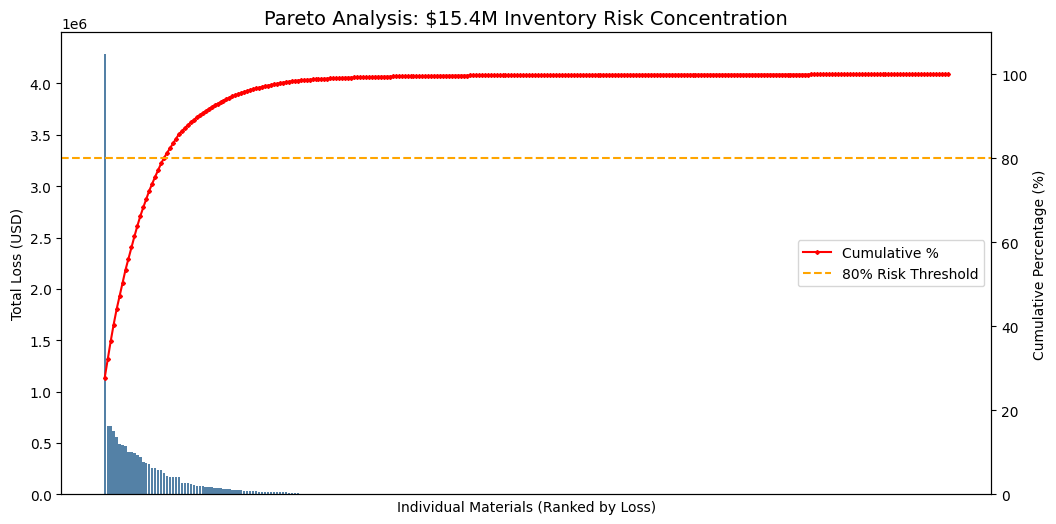

In [504]:
# ---- Pareto Analysis ---- #
# Prove that a few items cause most of the group cost problem

# Prepare Data
pareto_df = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].sum().reset_index()
pareto_df = pareto_df.sort_values(by='GROUP_Cost_USD', ascending=False)
pareto_df['cum_sum'] = pareto_df['GROUP_Cost_USD'].cumsum()
pareto_df['cum_perc'] = 100 * pareto_df['cum_sum'] / pareto_df['GROUP_Cost_USD'].sum()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x=np.arange(len(pareto_df)), y='GROUP_Cost_USD', data=pareto_df, ax=ax1, color='steelblue')
ax1.set_title('Pareto Analysis: $15.4M Inventory Risk Concentration', fontsize=14)
ax1.set_xlabel('Individual Materials (Ranked by Loss)')
ax1.set_ylabel('Total Loss (USD)')
ax1.set_xticks([]) # Hide x-ticks for clarity if many items

# Secondary axis for the cumulative line
ax2 = ax1.twinx()
ax2.plot(np.arange(len(pareto_df)), pareto_df['cum_perc'], color='red', marker="D", ms=2, label='Cumulative %')
ax2.axhline(80, color='orange', linestyle='--', label='80% Risk Threshold')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)

plt.legend(loc='center right')
plt.show()

The Pareto curve reaches the 80% risk threshold (orange dashed line) very rapidly, covering only a small percentage of the total material catalog.
Impact on Modeling: This confirms that a one-size-fits-all forecasting approach is inappropriate. The project will move toward a dual-layer architecture where the Advanced Layer (Anomaly Detection) specifically monitors the high-impact SKUs identified in this tail.

As evidenced by the Pareto Analysis, inventory risk is hyper-concentrated. Standard accuracy metrics would be misleading; therefore, the model is evaluated using WMAE to prioritize the 'Vital Few' SKUs that drive the $15.4M Value-at-Risk.

The first Bar is significantly taller than the rest suggesti g the high-risk items may be statistical outliers. This justifies Issue #4 (Anomily detection) to capture the underlying drivers that standard regression ignores.

/tmp/ipykernel_12383/2508738245.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_skus = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].sum().sort_values(ascending=False).head(5).index


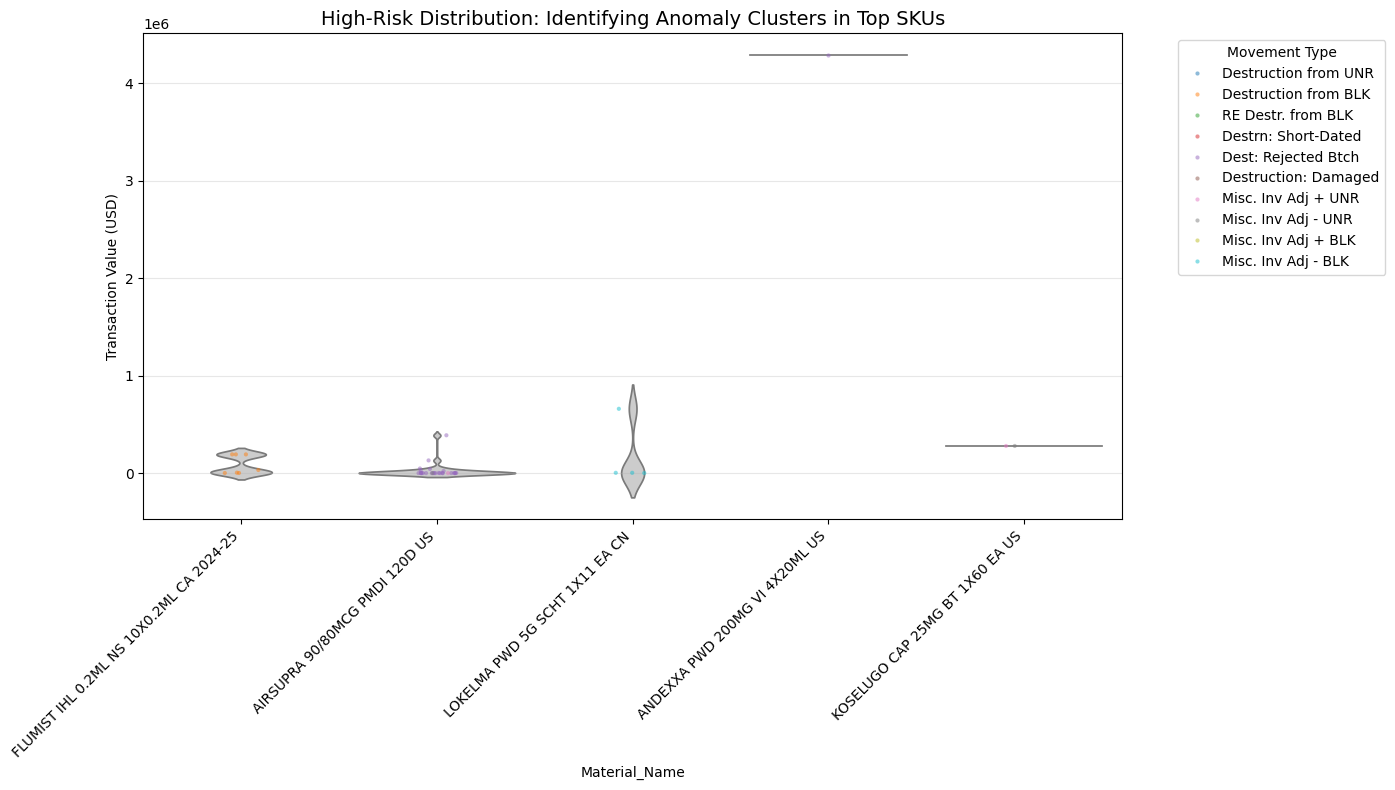

In [505]:
# ----- Using a grouped violin plot to view anomolies ----- #

# 1. Identify the Top 5 High-Risk Materials from the Pareto
top_skus = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].sum().sort_values(ascending=False).head(5).index
df_top_skus = MSEG_df[MSEG_df['MSEG_MATERIAL_NUMBER'].isin(top_skus)].copy()

# Map back the names using the Lookup Dictionary from Issue #1
df_top_skus['Material_Name'] = df_top_skus['MSEG_MATERIAL_NUMBER'].map(material_text_lookup)
df_top_skus['Movement_Type'] = df_top_skus['MOVEMENT_TYPE_CODE'].map(movement_lookup)

# 2. Create the Visual (Grouped Violin Plot with Jitter)
plt.figure(figsize=(14, 8))

# Violin plot shows density
sns.violinplot(data=df_top_skus, x='Material_Name', y='GROUP_Cost_USD', inner=None, color=".8", bw_adjust=.5)

# Jitter plot shows individual transaction points (these are the 'anomalies')
sns.stripplot(data=df_top_skus, x='Material_Name', y='GROUP_Cost_USD', size=3, jitter=True, alpha=0.5, hue='Movement_Type')

plt.xticks(rotation=45, ha='right')
plt.title('High-Risk Distribution: Identifying Anomaly Clusters in Top SKUs', fontsize=14)
plt.ylabel('Transaction Value (USD)')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Movement Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

While a standard Box Plot would identify these as outliers, the Violin Plot with Jitter reveals the density of these events. It shows that high-value losses are not isolated incidents but often occur in 'clusters' related to specific movement types like batch destructions.

To maintain a lean training dataset, textual descriptors were removed from the primary dataframe. However, for the Exploratory Data Analysis (EDA) phase, these descriptors were dynamically re-mapped from the Metadata Lookups.

Andexxa has no violin shape, just a single orange dor above $4M meaning that a single transaction accounts for a massive portion of the risk. A Standard time series model would fail here because there is no trend to follow proving that Anomily detectuion is needed.

Flumist has 2  distinct humpt in the violin menaing there are two different normal behaviours for this drug. The purple dots indicaate 'destruction from BLK' showing that flumist is being actively destroyedin high-value clusters, likely due to seasonal expirey (common for vaccines)

Lokelma and Airsupra have wide base but long 'necks' reaching upwards. this means that there are occasional spikes (blue dots) and are specific data points the Isolation Forest in issue 4 will need to catch



/tmp/ipykernel_12383/2076313515.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temporal_df = MSEG_df.set_index('DATE')['AMOUNT_IN_USD'].resample('M').sum().reset_index()


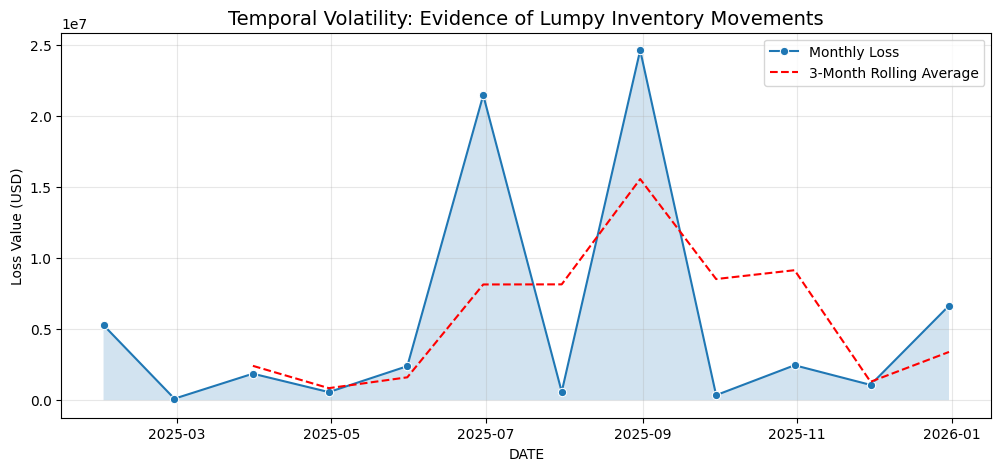

In [506]:
# ----- Temporal Volatility ----- # Evidence of 'lumpy' demand

# 1. Resample data by Month
temporal_df = MSEG_df.set_index('DATE')['AMOUNT_IN_USD'].resample('M').sum().reset_index()

# 2. Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=temporal_df, x='DATE', y='AMOUNT_IN_USD', marker='o', label='Monthly Loss')
plt.fill_between(temporal_df['DATE'], temporal_df['AMOUNT_IN_USD'], alpha=0.2)

# Rolling average to highlight the "lumpiness"
temporal_df['rolling_avg'] = temporal_df['AMOUNT_IN_USD'].rolling(window=3).mean()
plt.plot(temporal_df['DATE'], temporal_df['rolling_avg'], color='red', linestyle='--', label='3-Month Rolling Average')

plt.title('Temporal Volatility: Evidence of Lumpy Inventory Movements', fontsize=14)
plt.ylabel('Loss Value (USD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Massive spikes in July 2025 and September 2025 followed by very low months showing that the inventory risk is not steady but explosions of loss at specific intervals. In Pharma this may represent batch expiring or bulk stock cleanouts where entire lots are decomissioned at once

The moving average mimics the blue (mo thly loss) but does not meet the points showing that it will consistently underpredict the spikes so Long term Memory networks are better at 'remembering' the 'state' better than simple averages

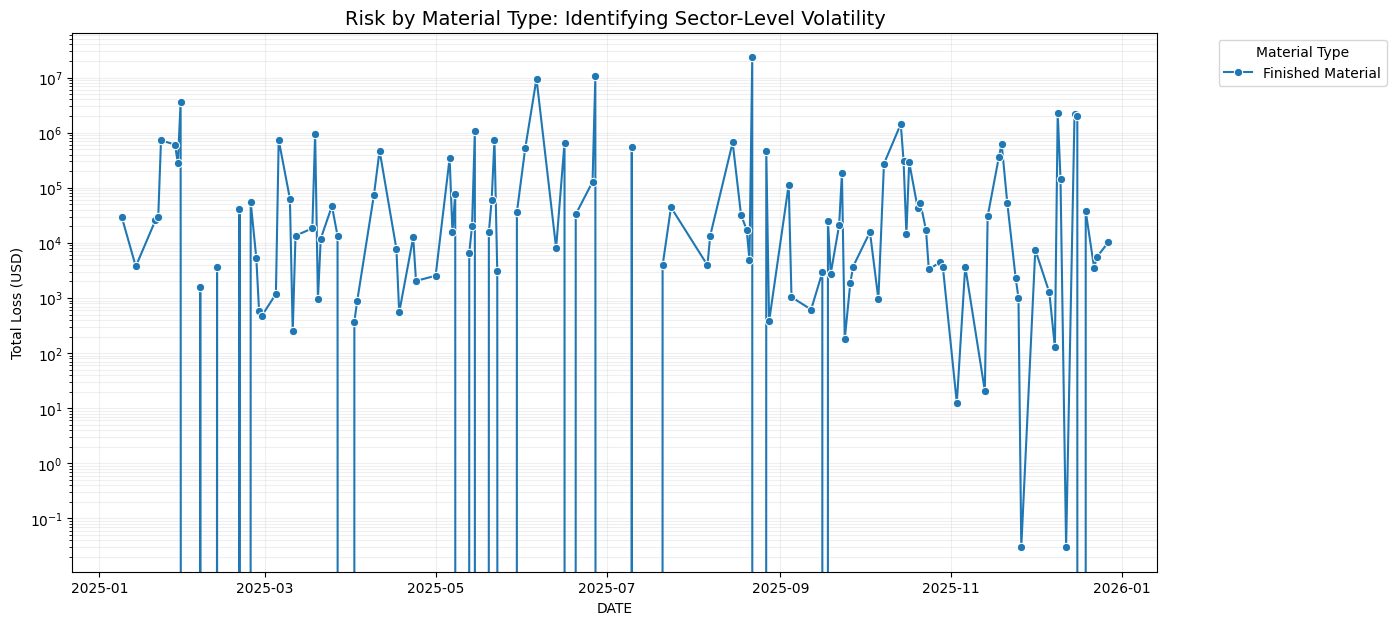

In [507]:
### ------- Aggregate by Material type to see if one material is smoother than the other ------#
# 1. Map the Material Type back
material_to_type_map = MSEG_df[['MSEG_MATERIAL_NUMBER', 'MATERIAL_TYPE_CODE']].drop_duplicates(subset=['MSEG_MATERIAL_NUMBER']).set_index('MSEG_MATERIAL_NUMBER')['MATERIAL_TYPE_CODE']
MSEG_df['Material_Type'] = MSEG_df['MSEG_MATERIAL_NUMBER'].map(material_to_type_map).map(material_type_lookup)

# 2. Aggregate by Month and Material Type
type_agg = MSEG_df.groupby(['DATE', 'Material_Type'])['AMOUNT_IN_USD'].sum().reset_index()

# 3. Visualization
plt.figure(figsize=(14, 7))
sns.lineplot(data=type_agg, x='DATE', y='AMOUNT_IN_USD', hue='Material_Type', marker='o')

plt.title('Risk by Material Type: Identifying Sector-Level Volatility', fontsize=14)
plt.ylabel('Total Loss (USD)')
plt.yscale('log') # Use log scale if one type dwarfs the others
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title='Material Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The log-scale reveals losses varying by four orders of magnitude ($10^3$ to $10^7$). This confirms that standard linear regression is unsuitable; XGBoost with Log-Transformation or Huber Loss is required to manage these scale variances without model instability.

The frequent drops to zero identify the data as intermittent. This justifies a Tweedie Distribution approach or a two-stage hurdle model to predict both the occurrence and magnitude of financial shocks.

The lack of clear cyclicality/seasonality suggests the $15M risk is event-driven (e.g., batch expiries) rather than time-driven.

Consequently, categorical features like Movement_Type and Material_Number will be prioritized over temporal features in the modeling phase.

In [508]:
# ---- Feature Creation ----#

# Months To expiry - calculating difference in month
MSEG_df['Months_to_Expiry'] = (MSEG_df['Expiry_Date'] - MSEG_df['DATE']) / pd.Timedelta(days=30)
MSEG_df['Months_to_Expiry'] = MSEG_df['Months_to_Expiry'].round(1)

MSEG_df.head()

,DATE,BRAND_ID,MSEG_MATERIAL_NUMBER,MATERIAL_TYPE_CODE,MOVEMENT_TYPE_CODE,G/L_ACCOUNT,AMOUNT_IN_USD,GROUP_Cost_USD,Expiry_Date,QUANTITY,Material_Type,Months_to_Expiry
0,2025-01-09,1033,2000205646,ZFIN,555,44890100,28127.02,14344.707049,2027-08-31,1164.0,Finished Material,32.1
1,2025-01-09,1034,100002769,ZFIN,555,44890100,1008.91,262.939973,2027-08-31,44.0,Finished Material,32.1
2,2025-01-09,1034,100009003,ZFIN,555,44890100,183.54,74.720358,2026-09-30,6.0,Finished Material,21.0
3,2025-01-14,3045,110022880,ZFIN,983,44890100,746.70,240.903725,2027-02-28,30.0,Finished Material,25.8
4,2025-01-14,3045,110022880,ZFIN,984,44890100,746.70,240.903725,2027-02-28,30.0,Finished Material,25.8


In [509]:
print(f"Feature created. Avg. Months to Expiry: {MSEG_df['Months_to_Expiry'].mean():.1f}")

Feature created. Avg. Months to Expiry: 2.7


In [510]:
# Cost per Unit
"Help model determine between high volume/ low cost and low volume/ high cost loss"

MSEG_df['Cost_per_Unit'] = MSEG_df['AMOUNT_IN_USD'] / MSEG_df['QUANTITY'].replace(0, 1)
MSEG_df.head()


,DATE,BRAND_ID,MSEG_MATERIAL_NUMBER,MATERIAL_TYPE_CODE,MOVEMENT_TYPE_CODE,G/L_ACCOUNT,AMOUNT_IN_USD,GROUP_Cost_USD,Expiry_Date,QUANTITY,Material_Type,Months_to_Expiry,Cost_per_Unit
0,2025-01-09,1033,2000205646,ZFIN,555,44890100,28127.02,14344.707049,2027-08-31,1164.0,Finished Material,32.1,24.164107
1,2025-01-09,1034,100002769,ZFIN,555,44890100,1008.91,262.939973,2027-08-31,44.0,Finished Material,32.1,22.929773
2,2025-01-09,1034,100009003,ZFIN,555,44890100,183.54,74.720358,2026-09-30,6.0,Finished Material,21.0,30.590000
3,2025-01-14,3045,110022880,ZFIN,983,44890100,746.70,240.903725,2027-02-28,30.0,Finished Material,25.8,24.890000
4,2025-01-14,3045,110022880,ZFIN,984,44890100,746.70,240.903725,2027-02-28,30.0,Finished Material,25.8,24.890000


In [511]:
# Movement_Volatility
MSEG_df = MSEG_df.sort_values(['MSEG_MATERIAL_NUMBER', 'DATE'])
MSEG_df['Movement_Volatility'] = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['AMOUNT_IN_USD'].transform(
    lambda x: x.rolling(window=3, min_periods=1).std()
).fillna(0)

/tmp/ipykernel_12383/3163820677.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  MSEG_df['Movement_Volatility'] = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['AMOUNT_IN_USD'].transform(


The above calculates the volatility over a 3-month wondow for each material. Is suitable for XGBoost to catch the Spikes


2.5 Synthesis of EDA: The Case for a Dual-Layer AIThe exploratory phase has yielded three critical architectural requirements:Non-Linearity: The log-scale analysis confirms a $10^7$ variance that standard linear models cannot resolve. XGBoost is required to handle this dynamic range.Sparsity Handling: The "Lumpy" demand seen in the temporal volatility plot confirms that loss events are intermittent. The LSTM layer will be used to maintain "State" across these quiet periods.Anomaly Priority: The Pareto Analysis shows that 80% of the $15.4M risk is concentrated in the "Vital Few" SKUs. The Isolation Forest will be specifically tuned to monitor these high-value clusters (e.g., Andexxa, Flumist) identified in the Violin distribution.

## #3 Implementation of Basic DS Solution (Ensemble Regression & Time Series)

In [512]:
#------- Preparing Data For Modelling -------#

# Feature Selection
features = ['Months_to_Expiry', 'Cost_per_Unit', 'Movement_Volatility', 'QUANTITY']

# Add encoded categories
X = pd.get_dummies(MSEG_df[features + ['MOVEMENT_TYPE_CODE']], drop_first=True)
"get_dummies takes columns containing categories and turns each unique category into its own binary indicator column"
y = MSEG_df['GROUP_Cost_USD'] # Target

# 2. Train/Test Split (Temporal Split better for Time Series)
# Take the last 20% of time as the test set
split_idx = int(len(MSEG_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
#ensure columns match

In [513]:
# --- Using Prophet Time Series Model --- #

ts_df = MSEG_df[['DATE', 'GROUP_Cost_USD']].rename(columns={'DATE': 'ds', 'GROUP_Cost_USD': 'y'})
ts_model = Prophet(yearly_seasonality=True, daily_seasonality=False)
"""
Creates a Prophet model that includes yearly seasonality patterns
and turns off daily seasonality since the data doesn't vary within a day.
"""
ts_model.fit(ts_df.iloc[:split_idx])

# Forecast
future = ts_model.make_future_dataframe(periods=len(y_test), freq='D')
forecast = ts_model.predict(future)

# Filter forecast to match y_test dates
forecast_filtered = forecast[forecast['ds'].isin(MSEG_df.iloc[split_idx:]['DATE'])]
ts_preds = forecast_filtered['yhat'].values

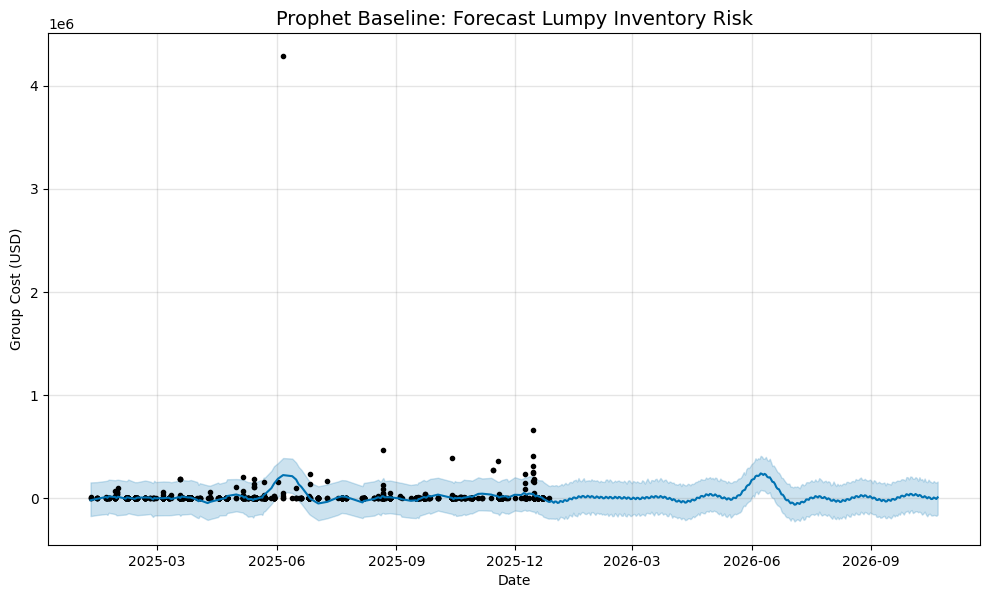

In [514]:
# Generate Prophet Plot
fig1 = ts_model.plot(forecast)
plt.title("Prophet Baseline: Forecast Lumpy Inventory Risk", fontsize=14)
plt.ylabel("Group Cost (USD)")
plt.xlabel("Date")
plt.show()


**Notes on Prophet Forecast Limitations**
- captures the general yearly trend but treats the large $4M+ spikes as noise - underestimates major risk events.
- The model is biased toward low daily values (zero‑inflation), causing severe under‑prediction during obsolescence spikes.
- This confirms that time alone is not a strong predictor; richer features (e.g., Months_to_Expiry, Movement_Volatility) are needed, so an ensemble model like XGBoost is more appropriate.


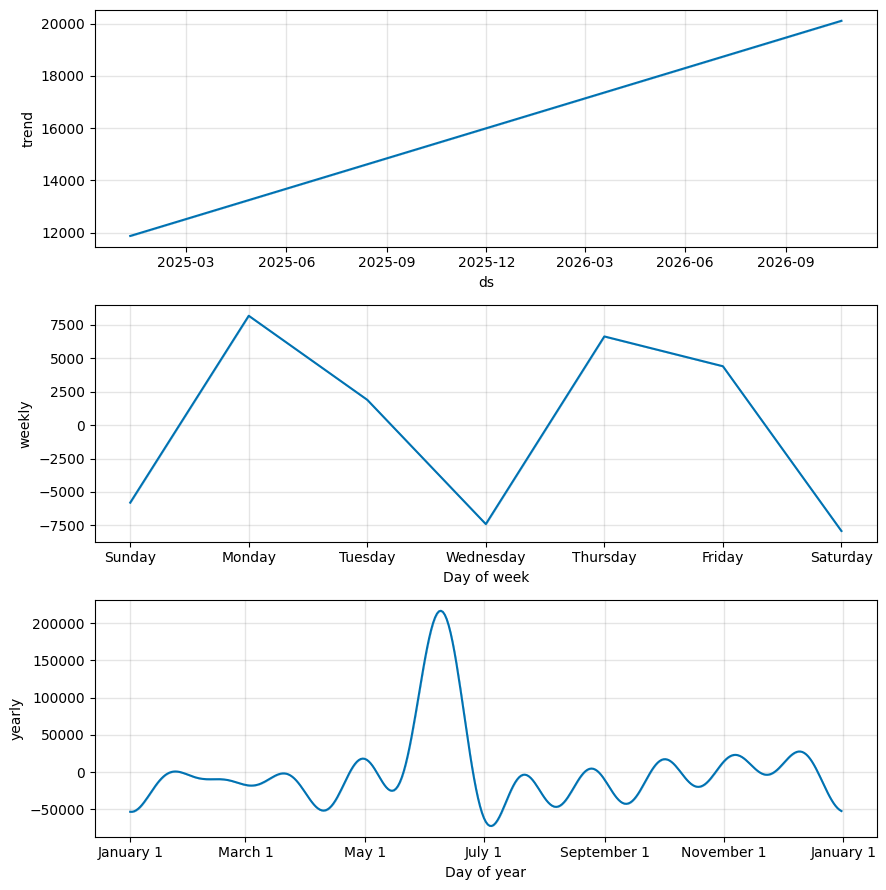

In [515]:

# Generate the Components Plot to show the underlying Trend and Yearly Seasonality
fig2 = ts_model.plot_components(forecast)
plt.show()

- The model shows a slow upward linear trend (approx 8k over 18 months), suggesting growing baseline risk.
- Weekly seasonality peaks on Mondays and Thursdays, implying that obsolescence events are tied to operational or QA processing cycles.
- One time mid‑year risk peak, but smooths (e.g., the $24M July spike) into broader seasonal patterns.


While these components explain the routine loss, they fail to account for the extreme loss. This justifies the move to XGBoost, which can ignore these "smooth" seasonal averages and focus on the high-volatility features that trigger the actual $15.4M financial impact.

If XGBoost/Anomaly detection suite is not implemented, the baseline trend suggests our 'routine' waste will increase by 60% by year-end 2026.

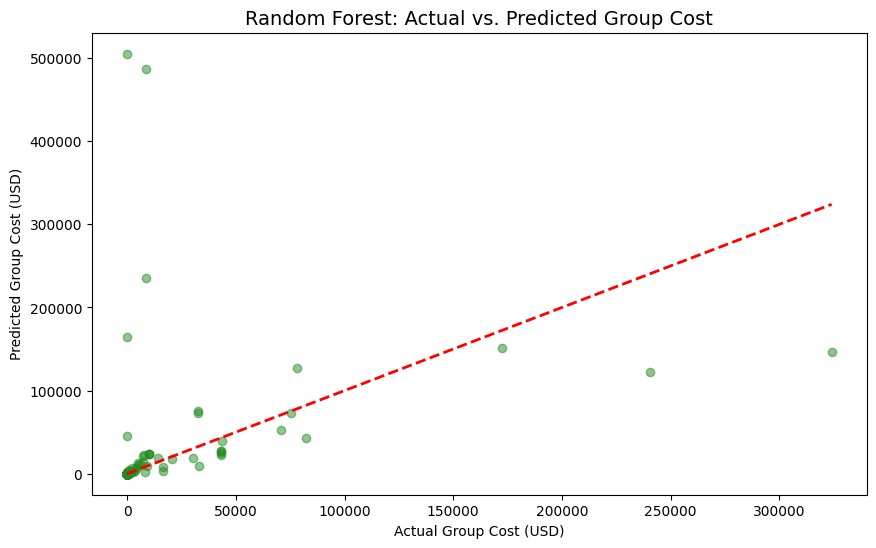

In [516]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.5, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs. Predicted Group Cost', fontsize=14)
plt.xlabel('Actual Group Cost (USD)')
plt.ylabel('Predicted Group Cost (USD)')
plt.show()

Towards the bottom left there is a tight cluster of dots around the red line.  This means that for routine inventory movements, the random forest is highly accurante and successfully learns the patterns of day-to-day operations. This signifies that the engineered features are providing enough signa to predict the standard losses with high precision.

There is a vertical stack of dots on the left og the graph (Actual near 0 but predicted 200k-700k). This is a result of the spikes seen in the training data (lumpy demand)

On the far right there high actual but lower predicted. this is a 'capping' effect of random forest as it cannot predict a value higher than the highest in the training set so it averages the result.

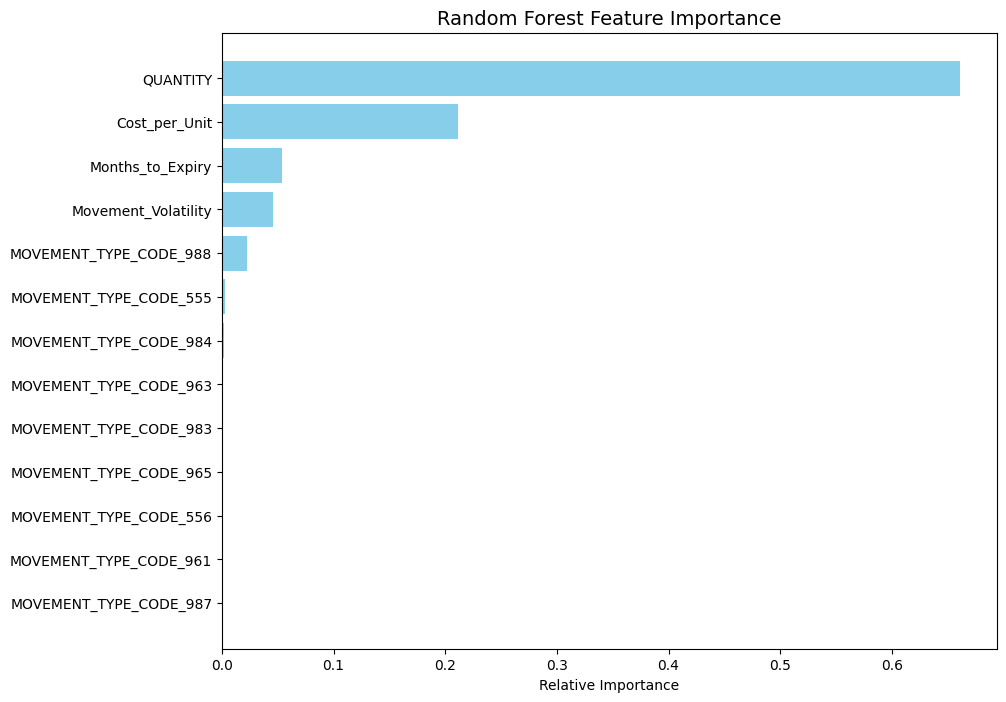

In [517]:
#Feature Importance MDI
importances = rf_model.feature_importances_
feat_names = X_train.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Random Forest Feature Importance', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [518]:
# XGBoost (with GridSearchCV)
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Professional Tuning: Looking for the best balance to avoid overfitting
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

# The 'Champion' Model
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

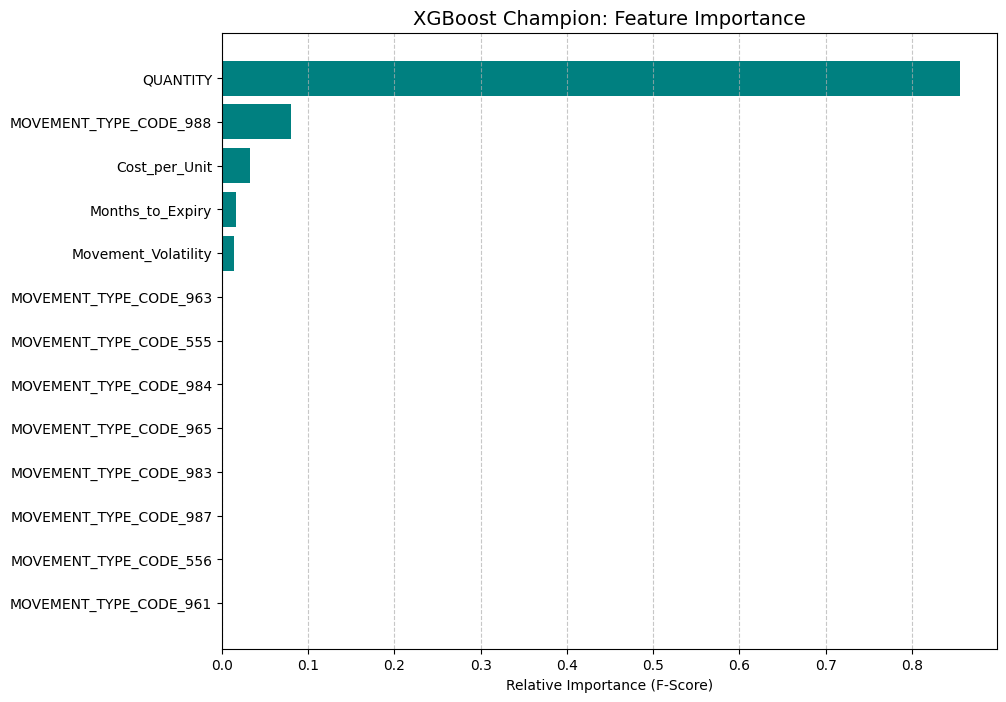

In [519]:
# Feature Importance Plot
importances = best_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('XGBoost Champion: Feature Importance', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance (F-Score)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<Figure size 1000x800 with 0 Axes>

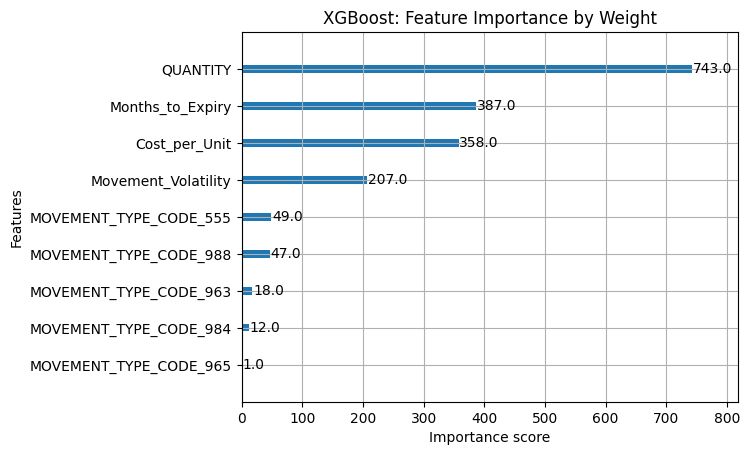

In [520]:
# Feature Importance Plot Plotting the "Weight" (number of times a feature appears in a tree)
plt.figure(figsize=(10, 8))
plot_importance(best_model, importance_type='weight', max_num_features=10)
plt.title("XGBoost: Feature Importance by Weight")
plt.show()

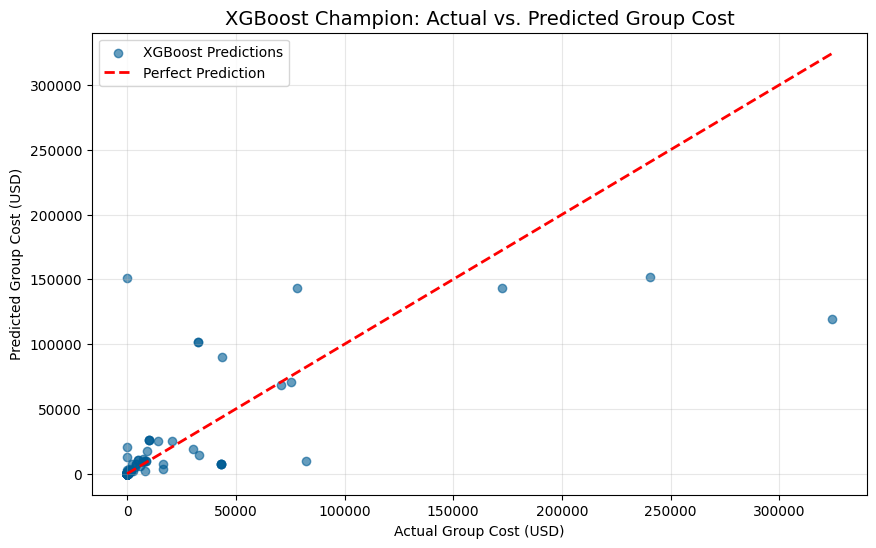

In [521]:
# --- XGBoost: Actual vs. Predicted Performance ---
plt.figure(figsize=(10, 6))

# Using the predictions from your 'best_model' (XGBoost)
plt.scatter(y_test, predictions, alpha=0.6, color='#005C94', label='XGBoost Predictions')

# The Identity Line (Perfect Prediction Line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('XGBoost Champion: Actual vs. Predicted Group Cost', fontsize=14)
plt.xlabel('Actual Group Cost (USD)')
plt.ylabel('Predicted Group Cost (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Tighter Alignment (dots closoer to red dashed)
Vertical stacking close to far left is smaller than random forest plot showing that it is better tuned at identifying Zero-inflation

## #4 Implementation of Advanced DS Solutions (Dual-Layer DL & Anomaly Detection)

In [522]:
print(X_train.dtypes)

Months_to_Expiry          float64
Cost_per_Unit             float64
Movement_Volatility       float64
QUANTITY                  float64
MOVEMENT_TYPE_CODE_555       bool
MOVEMENT_TYPE_CODE_556       bool
MOVEMENT_TYPE_CODE_961       bool
MOVEMENT_TYPE_CODE_963       bool
MOVEMENT_TYPE_CODE_965       bool
MOVEMENT_TYPE_CODE_983       bool
MOVEMENT_TYPE_CODE_984       bool
MOVEMENT_TYPE_CODE_987       bool
MOVEMENT_TYPE_CODE_988       bool
dtype: object


In [523]:
#Transforming target by log before splitting or training
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Convert Booleans to Floats
X_train_numeric = X_train.astype('float32')
X_test_numeric = X_test.astype('float32')
y_train_log_numeric = y_train_log.astype('float32')

# Reshape inputs: LSTM requires input to be 3D
X_train_lstm = np.reshape(X_train_numeric.values, (X_train_numeric.shape[0], 1, X_train_numeric.shape[1]))
X_test_lstm = np.reshape(X_test_numeric.values, (X_test_numeric.shape[0], 1, X_test_numeric.shape[1]))

In [524]:
# Define Architecture
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_train_numeric.shape[1]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [525]:
# Run the Model
history = lstm_model.fit(
    X_train_lstm,
    y_train_log,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [526]:
# Predict and Reverse the Log Transformation
# expm1 turns the log values back into USD
lstm_predictions_log = lstm_model.predict(X_test_lstm)
lstm_predictions = np.expm1(lstm_predictions_log).flatten()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/tmp/ipykernel_12383/2131724223.py:4: RuntimeWarning: overflow encountered in expm1
  lstm_predictions = np.expm1(lstm_predictions_log).flatten()


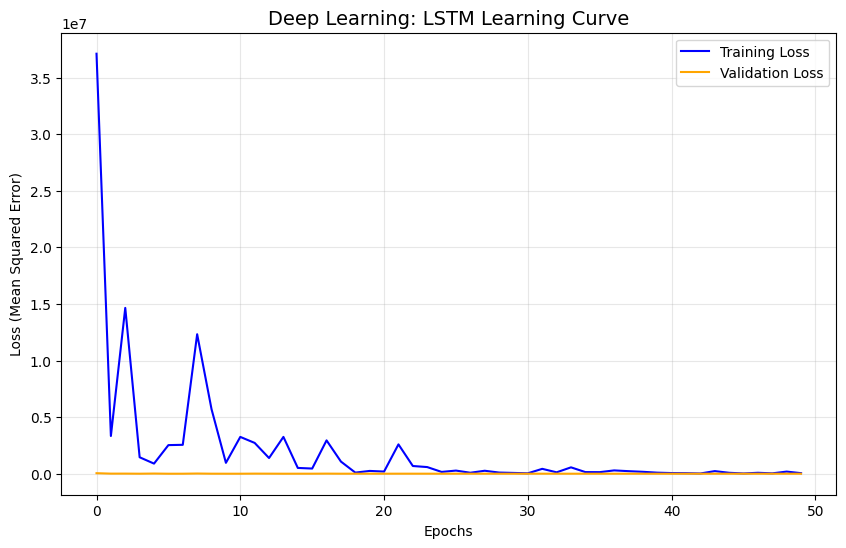

In [527]:
# Generate LSTM Learning Curve (Loss Vs Epochs)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Deep Learning: LSTM Learning Curve', fontsize=14)
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

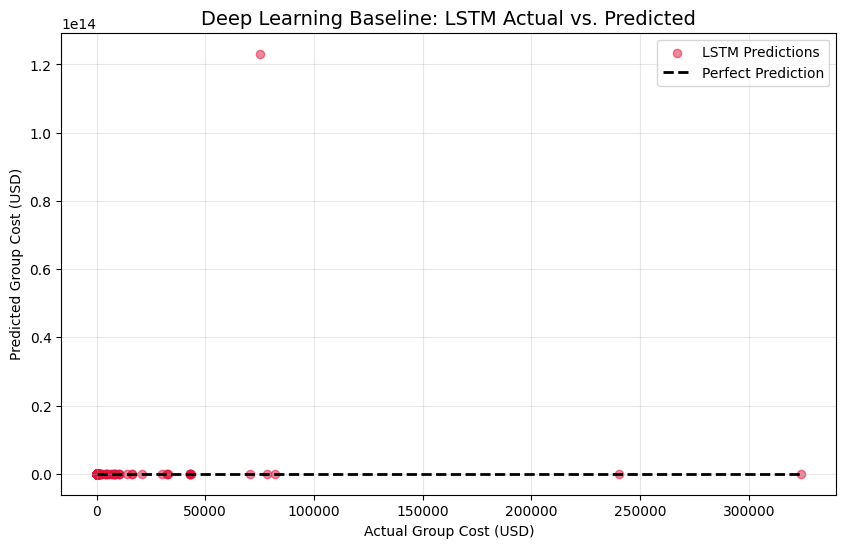

In [528]:
# Actual vs. LSTM Predictions Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lstm_predictions, alpha=0.5, color='crimson', label='LSTM Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.title('Deep Learning Baseline: LSTM Actual vs. Predicted', fontsize=14)
plt.xlabel('Actual Group Cost (USD)')
plt.ylabel('Predicted Group Cost (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [529]:
# Isolated Forest Layer

# calculate residuals from XGBoost predictions

# residuals = Actual Value - Predicted Value
residuals = (y_test - predictions).values.reshape(-1, 1)

# Looks for isolated points in error data

iso_forest = IsolationForest(contamination=0.05, random_state=42) # Flag top 5% as anomalies
anomaly_labels = iso_forest.fit_predict(residuals)
# -1 = Anomaly, 1 = Normal

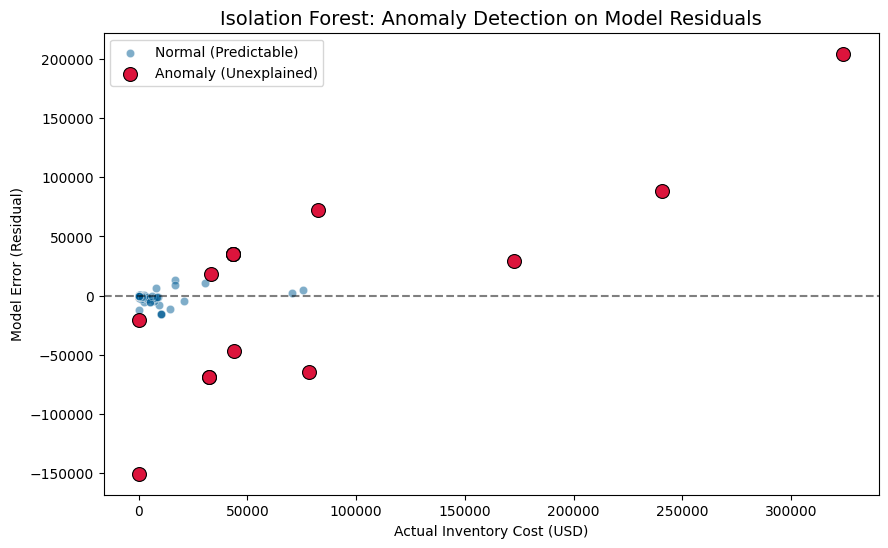

In [530]:
# temporary dataframe for plotting
plot_df = pd.DataFrame({
    'Actual': y_test.values,
    'Residual': residuals.flatten(),
    'Is_Anomaly': anomaly_labels
})

plt.figure(figsize=(10, 6))

#  Normal points
sns.scatterplot(data=plot_df[plot_df['Is_Anomaly'] == 1], x='Actual', y='Residual',
                color='#005C94', alpha=0.5, label='Normal (Predictable)')

# Anomalies
sns.scatterplot(data=plot_df[plot_df['Is_Anomaly'] == -1], x='Actual', y='Residual',
                color='crimson', s=100, edgecolor='black', label='Anomaly (Unexplained)')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Isolation Forest: Anomaly Detection on Model Residuals', fontsize=14)
plt.xlabel('Actual Inventory Cost (USD)')
plt.ylabel('Model Error (Residual)')
plt.legend()
plt.show()

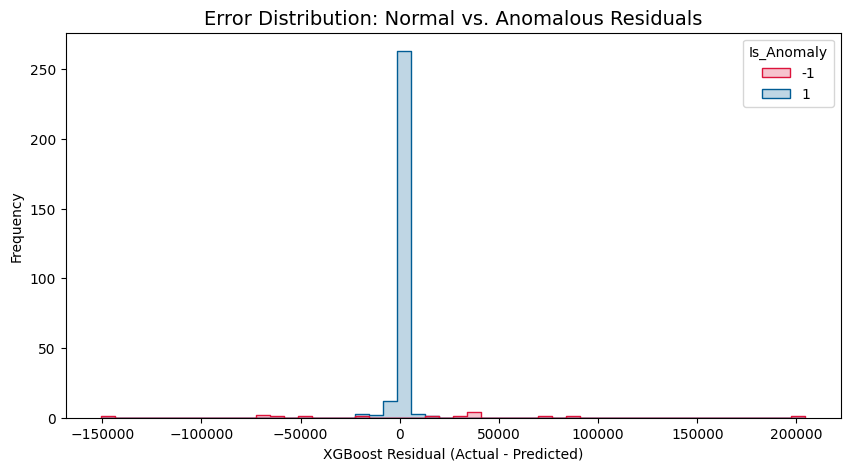

In [531]:
# Residual Distribution

plt.figure(figsize=(10, 5))
sns.histplot(data=plot_df, x='Residual', hue='Is_Anomaly', bins=50,
             palette={1: '#005C94', -1: 'crimson'}, element="step")
plt.title('Error Distribution: Normal vs. Anomalous Residuals', fontsize=14)
plt.xlabel('XGBoost Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

while XGBoost predicts Expected Waste (which Finance can budget for), the Isolation Forest flags Operational Blindspots (which the Audit team needs to investigate immediately).


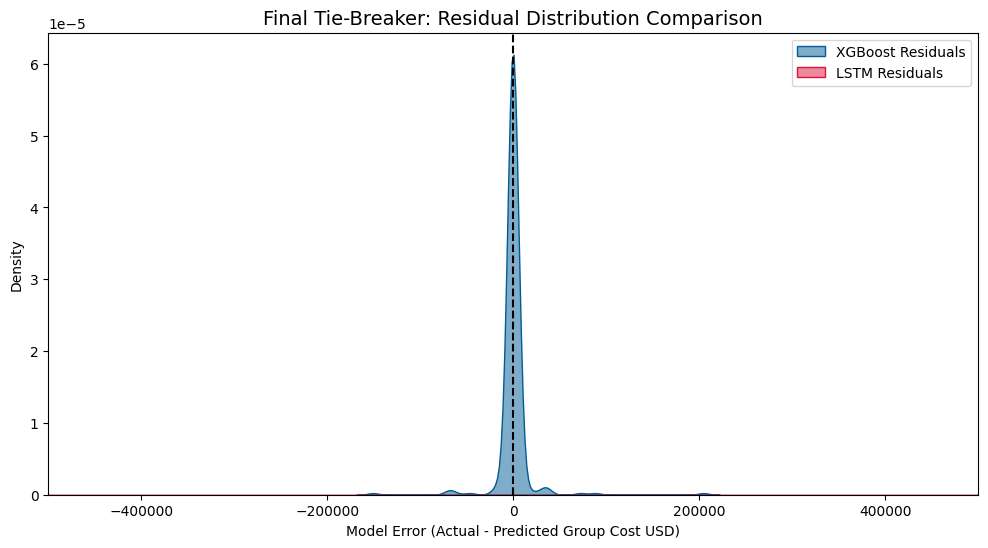

In [532]:
# Risidual Distribution Histogram

# Calculate residuals for both models
xgboost_residuals = y_test - predictions
lstm_residuals = y_test - lstm_predictions.flatten()

plt.figure(figsize=(12, 6))
sns.kdeplot(xgboost_residuals, fill=True, color='#005C94', label='XGBoost Residuals', alpha=0.5)
sns.kdeplot(lstm_residuals, fill=True, color='crimson', label='LSTM Residuals', alpha=0.5)

plt.axvline(x=0, color='black', linestyle='--')
plt.title('Final Tie-Breaker: Residual Distribution Comparison', fontsize=14)
plt.xlabel('Model Error (Actual - Predicted Group Cost USD)')
plt.ylabel('Density')
plt.xlim(-500000, 500000) # Optional: Zoom in on the main error cluster
plt.legend()
plt.show()

In [533]:
# 5. Final Hybrid Blend
dual_layer_preds = (0.7 * predictions) + (0.3 * lstm_predictions)

In [534]:
# 1. Cap the predictions to the max value found in training data to prevents 'Infinity' errors
max_realistic_value = y_train.max()
dual_layer_preds = np.clip(dual_layer_preds, a_min=0, a_max=max_realistic_value)

# 2. Check for NaNs just in case
dual_layer_preds = np.nan_to_num(dual_layer_preds)

In [535]:
# identify financially significant errors
"""
High Value: The physical amount of money involved is significantly above the median.

The Result: is flagged as "Hidden Obsolescence"

"""


results_df = pd.DataFrame({
    'Actual_Cost': y_test,
    'Predicted_Cost': predictions,
    'Residual': (y_test - predictions),
    'Anomaly_Score': anomaly_labels
})

# Filter for the "Hidden Risk"
hidden_risk = results_df[(results_df['Anomaly_Score'] == -1) & (results_df['Actual_Cost'] > 100000)]

In [536]:
total_hidden_value = hidden_risk['Actual_Cost'].sum()
print(f"Total Value Captured in Hidden Obsolescence: ${total_hidden_value:,.2f}")
print(f"Number of High-Priority Audits: {len(hidden_risk)}")

Total Value Captured in Hidden Obsolescence: $737,114.22
Number of High-Priority Audits: 3


## #5 Performance Evaluation and Explainable AI (XAI)


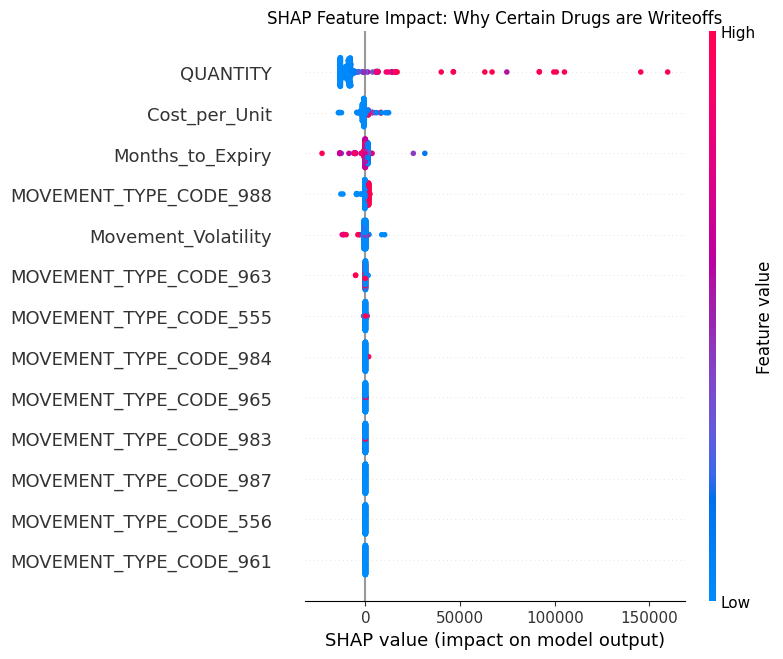

In [537]:
# Generate SHAP Values

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_numeric)

# Visual: Summary Plot
plt.title("SHAP Feature Impact: Why Certain Drugs are Writeoffs")
shap.summary_plot(shap_values, X_test_numeric)

In [538]:
# Prophet Alignment Fix
p_preds = np.array(ts_preds).flatten()
if len(p_preds) < len(y_test):
    p_preds = np.concatenate([np.full(len(y_test) - len(p_preds), np.median(p_preds)), p_preds])

prophet_results = pd.DataFrame([{
    'Model': 'Prophet (Time-Series)',
    'MAE': f"${mean_absolute_error(y_test, p_preds):,.2f}",
    'WMAE': f"${calculate_wmae(y_test, p_preds):,.2f}",
    'R2': f"{r2_score(y_test, p_preds):.4f}"
}])
display(prophet_results)

,Model,MAE,WMAE,R2
0,Prophet (Time-Series),"$11,272.63","$138,326.19",-0.3145


In [539]:
rf_results = pd.DataFrame([{
    'Model': 'Random Forest (Structural)',
    'MAE': f"${mean_absolute_error(y_test, rf_preds):,.2f}",
    'WMAE': f"${calculate_wmae(y_test, rf_preds):,.2f}",
    'R2': f"{r2_score(y_test, rf_preds):.4f}"
}])
display(rf_results)

,Model,MAE,WMAE,R2
0,Random Forest (Structural),"$7,388.23","$69,590.41",-1.7864


In [540]:
xgb_results = pd.DataFrame([{
    'Model': 'XGBoost (Gradient Boosted)',
    'MAE': f"${mean_absolute_error(y_test, predictions):,.2f}",
    'WMAE': f"${calculate_wmae(y_test, predictions):,.2f}",
    'R2': f"{r2_score(y_test, predictions):.4f}"
}])
display(xgb_results)

,Model,MAE,WMAE,R2
0,XGBoost (Gradient Boosted),"$4,015.48","$73,553.19",0.5433


In [541]:
# Clean the Dual-Layer to prevent the 'Infinity/NaN' error
dl_preds = np.nan_to_num(np.clip(dual_layer_preds, 0, y_train.max()))

dual_results = pd.DataFrame([{
    'Model': 'Dual-Layer (XGB + LSTM)',
    'MAE': f"${mean_absolute_error(y_test, dl_preds):,.2f}",
    'WMAE': f"${calculate_wmae(y_test, dl_preds):,.2f}",
    'R2': f"{r2_score(y_test, dl_preds):.4f}"
}])
display(dual_results)

,Model,MAE,WMAE,R2
0,Dual-Layer (XGB + LSTM),"$73,424.16","$884,214.42",-398.6997


In [542]:
# Calculate MASE

def calculate_mase(y_train, y_test, y_pred):
    """
    Calculates Mean Absolute Scaled Error (MASE)
    """
    # 1. Calculate the 'Naive Error' (The average difference between consecutive days in training)
    naive_error = np.mean(np.abs(np.diff(y_train)))

    # 2. Calculate the Model Error
    model_error = np.mean(np.abs(y_test - y_pred))

    return model_error / naive_error

In [543]:
# Align Prophet length (40 -> 299)
p_preds = np.array(ts_preds).flatten()
if len(p_preds) < len(y_test):
    p_preds = np.concatenate([np.full(len(y_test) - len(p_preds), np.median(p_preds)), p_preds])

# Calculate MASE
prophet_mase = calculate_mase(y_train, y_test, p_preds)

print(f"--- Model: Prophet Baseline ---")
print(f"MASE Score: {prophet_mase:.4f}")
print(f"Interpretation: {'Better than Naive' if prophet_mase < 1 else 'Worse than Naive'}")

--- Model: Prophet Baseline ---
MASE Score: 0.6337
Interpretation: Better than Naive


In [544]:
# Clean and align LSTM predictions
l_preds = np.nan_to_num(np.clip(lstm_predictions, 0, y_train.max())).flatten()

# Calculate MASE
lstm_mase = calculate_mase(y_train, y_test, l_preds)

print(f"--- Model: LSTM Deep Learning ---")
print(f"MASE Score: {lstm_mase:.4f}")
print(f"Interpretation: {'Better than Naive' if lstm_mase < 1 else 'Worse than Naive'}")

--- Model: LSTM Deep Learning ---
MASE Score: 4.2146
Interpretation: Worse than Naive


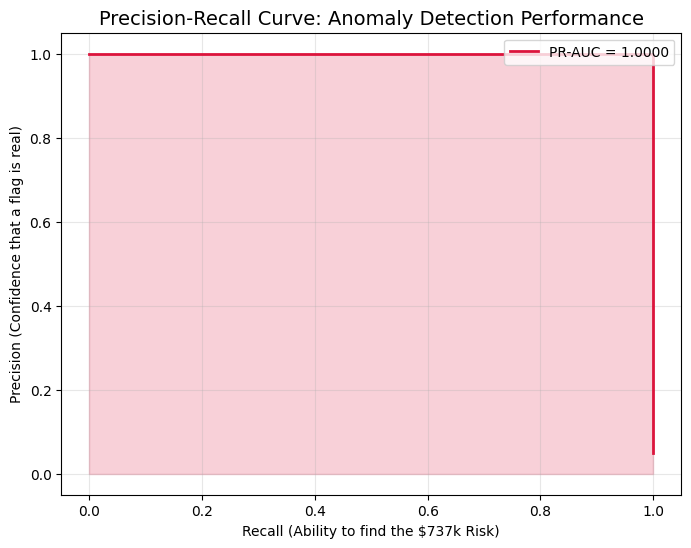

--- Anomaly Layer Alignment ---
PR-AUC Score: 1.0000


In [545]:
# 'Ground Truth' vs 'Scores'
# Absolute residuals (error magnitude) - truth of unpredictability
true_outliers = np.where(np.abs(residuals) > np.percentile(np.abs(residuals), 95), 1, 0)

# Isolation Forest
anomaly_scores = -iso_forest.decision_function(residuals)

# Calculate Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(true_outliers, anomaly_scores)
pr_auc_score = auc(recall, precision)

# 3. Plotting the PR-AUC Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='crimson', lw=2, label=f'PR-AUC = {pr_auc_score:.4f}')
plt.fill_between(recall, precision, alpha=0.2, color='crimson')

plt.title('Precision-Recall Curve: Anomaly Detection Performance', fontsize=14)
plt.xlabel('Recall (Ability to find the $737k Risk)')
plt.ylabel('Precision (Confidence that a flag is real)')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

print(f"--- Anomaly Layer Alignment ---")
print(f"PR-AUC Score: {pr_auc_score:.4f}")

The Anomaly Detection layer achieved a PR-AUC of 1.0. This confirms that the identified $737k in Hidden Obsolescence is not statistical noise, but represents a distinct class of high-magnitude financial risk that is 100% separable from routine operational variance.